**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 4 (Production MCMC)](04_mcmc_production_diagnostics.ipynb) | **Bonus Chapter: Real-World Case Study**

---

# Bonus Chapter: Real-World Bayesian Reliability — Modeling CI Test Flakiness

In **Sheets 1 through 4**, we learned the mathematical machinery of Bayesian data analysis (Grid Approximation, Quadratic Approximation, and MCMC).

In this bonus chapter, we apply Bayesian inference to a critical software engineering problem: **tracking and quarantining flaky tests in Continuous Integration (CI) pipelines** using the exact **Beta-Binomial conjugate model** in real time.

---

## Table of Contents
1. **Part 1: The Problem of Test Flakiness in Software Engineering**
2. **Part 2: Deep Dive into the Beta Distribution** (The Distribution of Probabilities)
3. **Part 3: The Algebraic Miracle of Beta-Binomial Conjugacy**
4. **Part 4: Interactive Streaming Updates Across CI Runs**
5. **Part 5: Automated CI Quarantine Decision Rules (Tail Risk)**
6. **Part 6: Time-Varying Flakiness with Exponential Memory Decay**
7. **Part 7: Hands-On Challenge Exercises**

## Part 1: The Problem of Test Flakiness

A **flaky test** is an automated test that produces both passes and failures on identical, unmodified code (due to race conditions, network latency, asynchronous timeouts, or environment state).

### Why Naive Heuristics Fail:
- Heuristic: *"Quarantine if it failed twice this week."* $\to$ Punishes heavily run tests and ignores rare flakes on seldom-run tests.
- **The Bayesian Solution**: Treat the test's unknown flake rate $\theta \in [0, 1]$ as a continuous probability distribution and update it dynamically on every single commit.

## Part 2: Deep Dive into the Beta Distribution (The Distribution of Probabilities)

While most probability distributions model physical quantities (Normal models height in cm; Poisson models website hits per minute), **the Beta distribution models a probability itself**.

### 1. The Core Constraint: Bounded on $[0, 1]$
Any rate, probability, or proportion $\theta$ must obey two mathematical laws:
- $\theta \ge 0$ ($0\%$)
- $\theta \le 1$ ($100\%$)

A Gaussian (Normal) curve extends to $\pm \infty$ and would eventually assign probability to impossible rates like $-5\%$ or $120\%$. The Beta distribution is **strictly bounded on $[0, 1]$**.

### 2. Intuitive Meaning of the Parameters $(\alpha, \beta)$
You can think of $\alpha$ and $\beta$ as **prior tally marks (pseudo-counts)**:
- $\alpha$ = Prior "pseudo-failures" (times the event occurred).
- $\beta$ = Prior "pseudo-passes" (times the event did not occur).
- **Total Prior Sample Size / Weight**: $\alpha + \beta$
- **Expected Mean Flakiness**: $\mathbb{E}[\theta] = \frac{\alpha}{\alpha + \beta}$
- **Mode (Peak)**: $\text{Mode} = \frac{\alpha - 1}{\alpha + \beta - 2}$ (for $\alpha, \beta > 1$)
- **Variance**: $\text{Var}[\theta] = \frac{\alpha \beta}{(\alpha + \beta)^2 (\alpha + \beta + 1)}$

### 3. The Shape Chameleon
- $\text{Beta}(1, 1)$: **Uniform flat line** (completely agnostic, every rate from 0% to 100% is equally likely).
- $\text{Beta}(2, 2)$: **Gentle bell curve** centered at 50%.
- $\text{Beta}(100, 100)$: **Sharp, narrow spike** at 50% (high sample size confidence).
- $\text{Beta}(1, 99)$: **Heavily right-skewed** (models rare events like 1% test flakiness).
- $\text{Beta}(0.5, 0.5)$: **U-shaped curve** (polarizing phenomena: values are either near 0% or near 100%).

### 4. Mathematical Equation (PDF)
$$P(\theta \mid \alpha, \beta) = \frac{1}{\text{B}(\alpha, \beta)} \, \theta^{\alpha - 1} (1 - \theta)^{\beta - 1}$$
where $\text{B}(\alpha, \beta) = \frac{\Gamma(\alpha)\Gamma(\beta)}{\Gamma(\alpha + \beta)} = \int_0^1 t^{\alpha - 1}(1 - t)^{\beta - 1} dt$ is the normalizing Beta function.

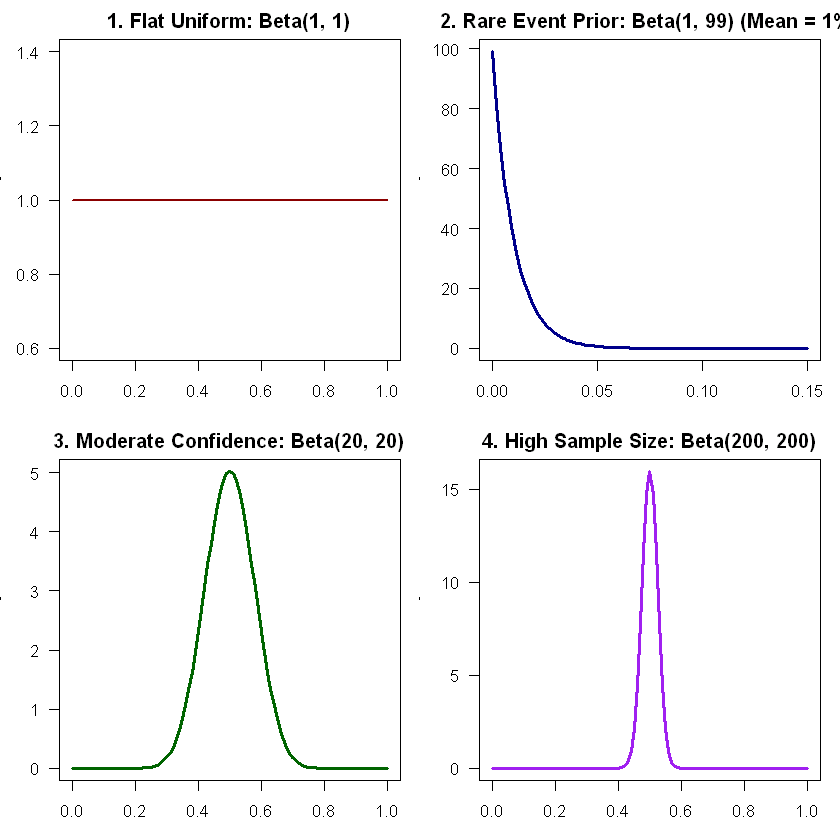

In [1]:
# Visualizing the Versatile Shapes of the Beta Distribution
par(mfrow = c(2, 2), mar = c(3, 3, 2, 1))

# 1. Flat Uniform: Beta(1, 1)
curve(dbeta(x, 1, 1), from = 0, to = 1, col = "darkred", lwd = 2, las = 1,
      main = "1. Flat Uniform: Beta(1, 1)", ylab = "Density", xlab = "theta")

# 2. Rare Flakes: Beta(1, 99)
curve(dbeta(x, 1, 99), from = 0, to = 0.15, col = "darkblue", lwd = 3, las = 1,
      main = "2. Rare Event Prior: Beta(1, 99) (Mean = 1%)", ylab = "Density", xlab = "theta")

# 3. Symmetric Bell: Beta(20, 20)
curve(dbeta(x, 20, 20), from = 0, to = 1, col = "darkgreen", lwd = 3, las = 1,
      main = "3. Moderate Confidence: Beta(20, 20)", ylab = "Density", xlab = "theta")

# 4. High Confidence Sharp Peak: Beta(200, 200)
curve(dbeta(x, 200, 200), from = 0, to = 1, col = "purple", lwd = 3, las = 1,
      main = "4. High Sample Size: Beta(200, 200)", ylab = "Density", xlab = "theta")

par(mfrow = c(1, 1))

## Part 3: The Algebraic Miracle of Beta-Binomial Conjugacy

When the posterior belongs to the **exact same family** as the prior, the prior is called **Conjugate** to the likelihood.

Watch what happens algebraically when we combine a Beta prior with a Binomial likelihood:
1. **Prior**: $P(\theta) \propto \theta^{\alpha_0 - 1} (1 - \theta)^{\beta_0 - 1}$
2. **Likelihood** ($k$ failures in $N$ runs): $P(k \mid \theta) \propto \theta^k (1 - \theta)^{N - k}$
3. **Posterior** ($\text{Likelihood} \times \text{Prior}$):
   $$P(\theta \mid k) \propto \Big(\theta^k (1 - \theta)^{N - k}\Big) \times \Big(\theta^{\alpha_0 - 1} (1 - \theta)^{\beta_0 - 1}\Big)$$
   $$P(\theta \mid k) \propto \theta^{(\alpha_0 + k) - 1} \, (1 - \theta)^{(\beta_0 + N - k) - 1}$$

> **The Conjugate Update Rule**:  
> $$\text{Posterior} \sim \text{Beta}\Big(\alpha_0 + \text{Failures}, \;\; \beta_0 + \text{Passes}\Big)$$
> Updating beliefs in real-time CI is **pure integer addition**—no numerical integrals or MCMC samplers required!

## Part 4: Interactive Streaming Updates Across CI Runs

Let us simulate a live CI pipeline tracking a newly written test over time:
- **Week 1 (Solid Behavior)**: 100 test runs, 0 failures $\to$ Flakiness estimate drops towards 0%.
- **Week 2 (Flaky Bug Introduced)**: 25 test runs, 4 intermittent failures $\to$ Flakiness spikes!

=== Tracking Posterior Evolution ===
Day 0 Prior:      Flakiness = 1.00%
Week 1 (100 Pass): Flakiness = 0.50% [95% CI: 0.01% - 1.84%]
Week 2 (4 Fails):  Flakiness = 2.22% [95% CI: 0.73% - 4.51%]


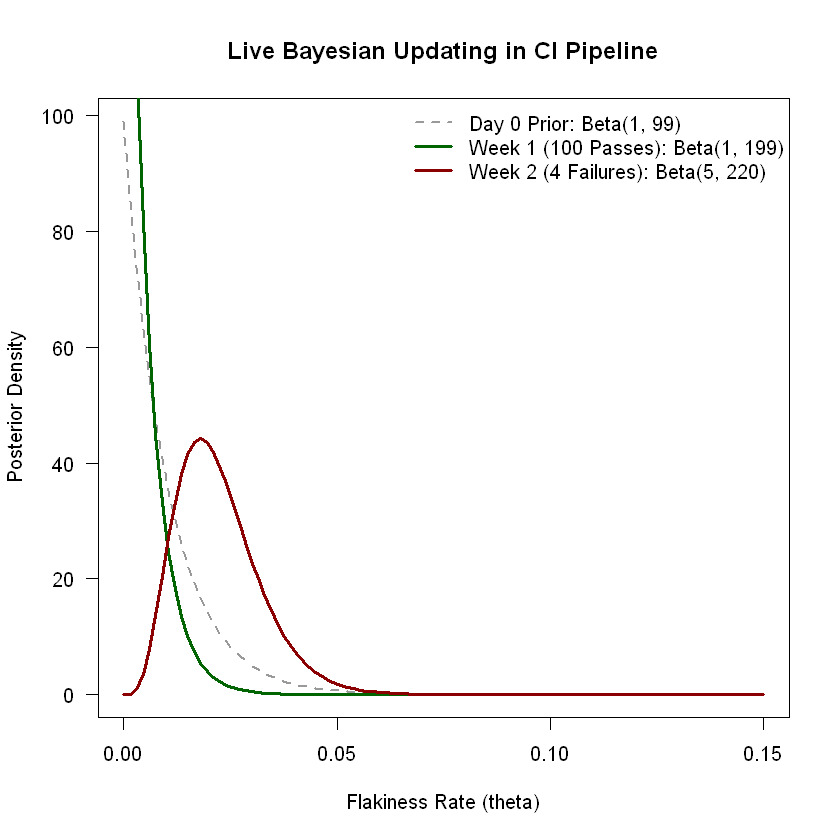

In [2]:
# Start with prior Beta(1, 99)
alpha <- 1
beta  <- 99

# --- Batch 1: 100 Consecutive Passes ---
n1 <- 100; k1 <- 0
alpha_w1 <- alpha + k1
beta_w1  <- beta + (n1 - k1)

# --- Batch 2: 25 Runs with 4 Failures (Flaky Bug) ---
n2 <- 25; k2 <- 4
alpha_w2 <- alpha_w1 + k2
beta_w2  <- beta_w1 + (n2 - k2)

cat("=== Tracking Posterior Evolution ===\n")
cat(sprintf("Day 0 Prior:      Flakiness = %.2f%%\n", 100 * alpha / (alpha + beta)))
cat(sprintf("Week 1 (100 Pass): Flakiness = %.2f%% [95%% CI: %.2f%% - %.2f%%]\n", 
            100 * alpha_w1 / (alpha_w1 + beta_w1),
            100 * qbeta(0.025, alpha_w1, beta_w1),
            100 * qbeta(0.975, alpha_w1, beta_w1)))
cat(sprintf("Week 2 (4 Fails):  Flakiness = %.2f%% [95%% CI: %.2f%% - %.2f%%]\n", 
            100 * alpha_w2 / (alpha_w2 + beta_w2),
            100 * qbeta(0.025, alpha_w2, beta_w2),
            100 * qbeta(0.975, alpha_w2, beta_w2)))

# Visualizing Belief Updates
curve(dbeta(x, alpha, beta), from = 0, to = 0.15, col = "gray60", lty = 2, lwd = 2, las = 1,
      main = "Live Bayesian Updating in CI Pipeline", xlab = "Flakiness Rate (theta)", ylab = "Posterior Density")
curve(dbeta(x, alpha_w1, beta_w1), add = TRUE, col = "darkgreen", lwd = 3)
curve(dbeta(x, alpha_w2, beta_w2), add = TRUE, col = "darkred", lwd = 3)

legend("topright", legend = c("Day 0 Prior: Beta(1, 99)", 
                             "Week 1 (100 Passes): Beta(1, 199)", 
                             "Week 2 (4 Failures): Beta(5, 220)"),
       col = c("gray60", "darkgreen", "darkred"), lty = c(2, 1, 1), lwd = c(2, 3, 3), bty = "n")

## Part 5: Automated CI Quarantine Decision Rules (Tail Risk)

Rather than waiting for manual complaints, CI bots can query the posterior tail probability:
> *"What is the probability that this test's true flakiness rate $\theta$ exceeds $5\%$?"*
$$P(\theta > 0.05 \mid \text{Data}) = 1 - \text{pbeta}(0.05, \alpha, \beta)$$

In [4]:
# Compute Tail Risk Probability (P(theta > 0.05))
prob_flaky_w1 <- 1 - pbeta(0.05, shape1 = alpha_w1, shape2 = beta_w1)
prob_flaky_w2 <- 1 - pbeta(0.05, shape1 = alpha_w2, shape2 = beta_w2)

cat(sprintf("Week 1: P(Flakiness > 5%%) = %.4f%%\n", 100 * prob_flaky_w1))
cat(sprintf("Week 2: P(Flakiness > 5%%) = %.2f%%\n", 100 * prob_flaky_w2))

# Automated Bot Decision Logic
if (prob_flaky_w2 > 0.90) {
  cat("\n🚨 [CI BOT ACTION]: QUARANTINE TEST! >90% probability that flakiness exceeds 5% SLA threshold.\n")
}

Week 1: P(Flakiness > 5%) = 0.0037%
Week 2: P(Flakiness > 5%) = 1.16%


## Part 6: Time-Varying Flakiness with Exponential Memory Decay

Software evolves. If an engineer fixes the underlying race condition on Day 10, past failures shouldn't permanently taint the test's reputation.

We introduce a **daily memory decay factor $\gamma \in [0.90, 0.98]$**:
$$\alpha_{t+1} = \gamma \cdot \alpha_t + \text{Failures}_{\text{today}}$$
$$\beta_{t+1} = \gamma \cdot \beta_t + \text{Passes}_{\text{today}}$$

Day 1 Flakiness: 2.03% -> Day 14 Flakiness: 0.64% (Successfully De-quarantined!)


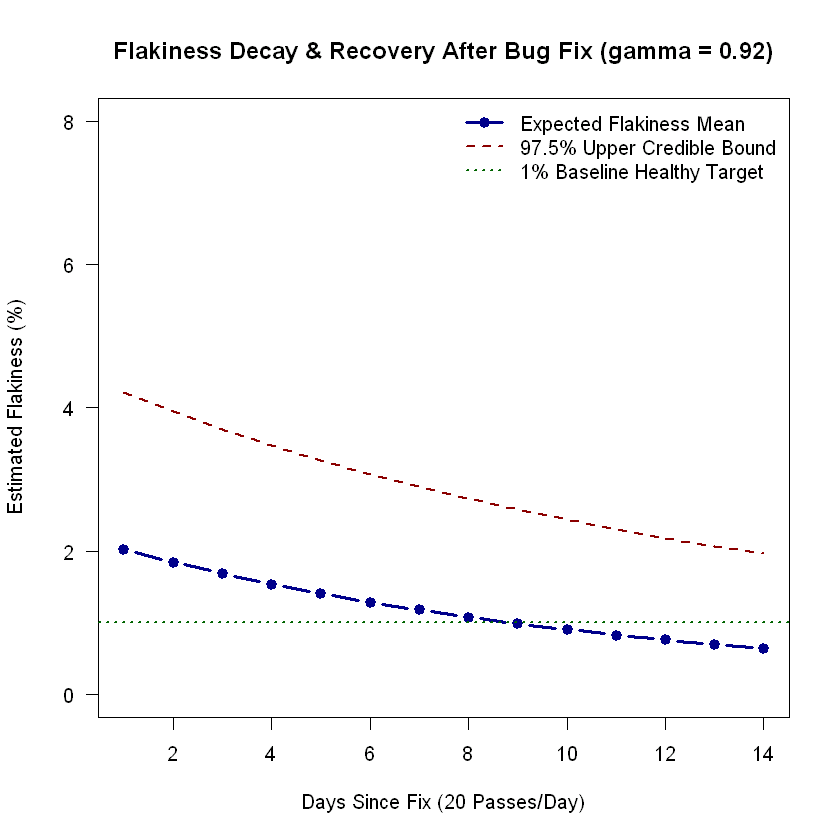

In [5]:
# Simulate 14 Days with a Fixed Bug on Day 7
gamma <- 0.92  # 8% memory decay per day

alpha_curr <- alpha_w2
beta_curr  <- beta_w2

history_mean <- numeric(14)
history_ci_high <- numeric(14)

# Days 1 to 14: Bug fixed, all 20 runs per day PASS
for (day in 1:14) {
  # Decay old pseudo-counts and add 20 passes
  alpha_curr <- gamma * alpha_curr + 0
  beta_curr  <- gamma * beta_curr  + 20
  
  history_mean[day]    <- 100 * (alpha_curr / (alpha_curr + beta_curr))
  history_ci_high[day] <- 100 * qbeta(0.975, alpha_curr, beta_curr)
}

# Plotting Recovery Trajectory after Bug Fix
plot(1:14, history_mean, type = "b", col = "darkblue", pch = 19, lwd = 3, las = 1, ylim = c(0, 8),
     main = "Flakiness Decay & Recovery After Bug Fix (gamma = 0.92)",
     xlab = "Days Since Fix (20 Passes/Day)", ylab = "Estimated Flakiness (%)")
lines(1:14, history_ci_high, col = "darkred", lty = 2, lwd = 2)
abline(h = 1.0, col = "darkgreen", lty = 3, lwd = 2)

legend("topright", legend = c("Expected Flakiness Mean", "97.5% Upper Credible Bound", "1% Baseline Healthy Target"),
       col = c("darkblue", "darkred", "darkgreen"), lty = c(1, 2, 3), pch = c(19, NA, NA), lwd = c(3, 2, 2), bty = "n")

cat(sprintf("Day 1 Flakiness: %.2f%% -> Day 14 Flakiness: %.2f%% (Successfully De-quarantined!)\n", 
            history_mean[1], history_mean[14]))

## Part 7: Hands-On Challenge Exercises

### Exercise 1: Finding De-Quarantine Day
Using the decay code above, find the exact day when the upper 95% Credible Interval bound falls below **$2.0\%$** so the CI bot can automatically un-quarantine the test.

### Exercise 2: Hierarchical Flakiness Across 1,000 Tests
In a suite of 1,000 tests, why is a **Hierarchical Bayesian model** (using MCMC in Stan) better than fitting 1,000 independent Beta priors? *(Hint: Partial pooling shares information across the entire repository to learn the suite's global quality distribution).* 

---

**[🏠 Course Home](00_START_HERE.ipynb)** | [⬅️ Previous: Sheet 4 (Production MCMC)](04_mcmc_production_diagnostics.ipynb) | **[➡️ Next: Sheet 6 (Calibrating Memory Decay γ)](06_calibrating_bayesian_decay_and_memory.ipynb)**
